# Longitudinal velocity reference audit

## Read this before interpreting any velocity plot

**There is no directly measured instantaneous ground truth in these data.** A
scan records anatomy at one visit; it does not record the time derivative at
that visit. This report therefore keeps three different observed quantities
separate:

1. **Observed — adjacent interval** is the mesh change between visits divided by
   elapsed years. It is an average over that interval and amplifies independent
   visit-specific error.
2. **Observed — first-to-last** is a longer-interval average. It is usually more
   stable but cannot show acceleration within a subject.
3. **Observed — fitted trajectory** is the derivative of a smooth trajectory
   fitted to all eligible visits. Its estimator was chosen by predicting held-out
   validation visits, then frozen before test evaluation. It is the primary
   reference here, but it remains an inferred quantity.

Source meshes and trained models are read-only. The analysis-only rigid step
uses rotation and translation, never scale or reflection. Current models share
one test cohort. Legacy ODE and BrainODE results use a separate cohort and are
never numerically pooled with current results.


## Load completed results

This notebook does no training, mesh extraction, nearest-neighbour evaluation,
or bootstrap resampling. Those computations are cached by the scripts. Running
all notebook cells should therefore be quick.


In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from IPython.display import display, Markdown

TASK_NAME = "task4_velocity_reference_audit_v2"
candidates = [Path.cwd(), *Path.cwd().parents]
TASK = next((p for p in candidates if p.name == TASK_NAME), None)
if TASK is None:
    TASK = (Path.cwd() / "examples/ADNI_1_LHipp_LLV_No_MCI_synthseg_minimal_smooth" / TASK_NAME).resolve()
CACHE = TASK / "generated_cache"
sys.path.insert(0, str(TASK / "scripts"))
from velocity_core import subject_group_mean

manifest = json.loads((CACHE / "manifest.json").read_text())
selected = json.loads((CACHE / "selected_estimator.json").read_text())
tables = CACHE / "tables"
reference = pd.read_csv(tables / "velocity_reference_per_scan.csv", dtype={"scan_id": str, "subject_id": str})
intervals = pd.read_csv(tables / "adjacent_interval_diagnostics.csv", dtype={"source_scan_id": str, "target_scan_id": str})
stability = pd.read_csv(tables / "leave_one_visit_out_derivative_stability.csv")
val_summary = pd.read_csv(tables / "val_estimator_summary.csv")
test_summary = pd.read_csv(tables / "test_estimator_summary.csv")
volume_ci = pd.read_csv(tables / "diagnosis_volume_slope_bootstrap.csv")
mixed = pd.read_csv(tables / "volume_within_between_mixed_effects.csv")
current_surface = pd.read_csv(tables / "current_model_surface_group_comparison.csv")
comparator_sensitivity = pd.read_csv(tables / "current_model_comparator_sensitivity.csv")
legacy_surface = pd.read_csv(tables / "legacy_model_surface_group_comparison.csv")
latent = pd.read_csv(tables / "latent_model_vs_fitted_reference_per_scan.csv", dtype={"scan_id": str, "subject_id": str})
surface_scan = pd.read_csv(tables / "current_model_surface_scalar_per_scan.csv", dtype={"scan_id": str, "subject_id": str})

COLORS = {"CN": "#2b6cb0", "AD": "#c53030"}
METHOD_COLORS = {"PCA": "#4c78a8", "Spiral": "#f58518", "Adaptive": "#54a24b", "INR": "#b279a2", "Latent ODE": "#e45756", "BrainODE": "#72b7b2", "PCA Cocycle": "#4c78a8", "INR Cocycle": "#b279a2"}
print(f"Cache: {manifest['status']} ({manifest['mode']})")
print(f"Validation-selected estimator: {selected['candidate_label']}")
print(f"Eligible validation/test subjects: {manifest['counts']['val']['subjects']} / {manifest['counts']['test']['subjects']}")


Cache: complete (full)
Validation-selected estimator: Linear surface (rigid removed)
Eligible validation/test subjects: 57 / 58


## Cohort and eligibility

At least three visits are required because an interior visit must be held out
while at least two visits remain for a linear trajectory. Two-visit subjects are
listed as exclusions rather than treated as validated instantaneous evidence.
Diagnosis counts below are subject counts, not scan counts.


In [2]:
coverage = (reference.groupby(["split", "diagnosis"])
            .agg(subjects=("subject_id", "nunique"), scans=("scan_id", "nunique"),
                 median_visits=("subject_id", lambda x: x.value_counts().median()),
                 age_min=("age_years", "min"), age_max=("age_years", "max"))
            .reset_index())
display(coverage.round(2))
display(pd.DataFrame([
    {"split": split, **item}
    for split, items in manifest["excluded_subjects"].items()
    for item in items
]))


,split,diagnosis,subjects,scans,median_visits,age_min,age_max
0,test,AD,25,88,3.0,56.5,89.80
1,test,CN,33,183,5.0,63.9,94.18
2,val,AD,25,91,4.0,55.9,88.60
3,val,CN,32,170,5.0,67.6,93.07


,split,subject_id,reason,visits
0,val,1212,fewer_than_3_visits,2
1,val,1289,fewer_than_3_visits,2
2,val,1334,fewer_than_3_visits,2
3,val,4001,fewer_than_3_visits,2
4,test,4589,fewer_than_3_visits,2
5,test,691,fewer_than_3_visits,2
6,test,929,fewer_than_3_visits,2


## Choosing the fitted-trajectory estimator

Each validation interior visit is removed, the trajectory is fitted to the
remaining visits, and the omitted mesh is predicted. **Vertex RMSE** is the root
mean squared Euclidean distance between corresponding vertices. **ASSD** is the
average symmetric distance between the two surfaces. **HD95** is the 95th
percentile symmetric surface distance and is more sensitive to local failures.
**Log-volume error** measures proportional volume mismatch. Lower is better for
all four. The test table is descriptive only and did not affect selection.


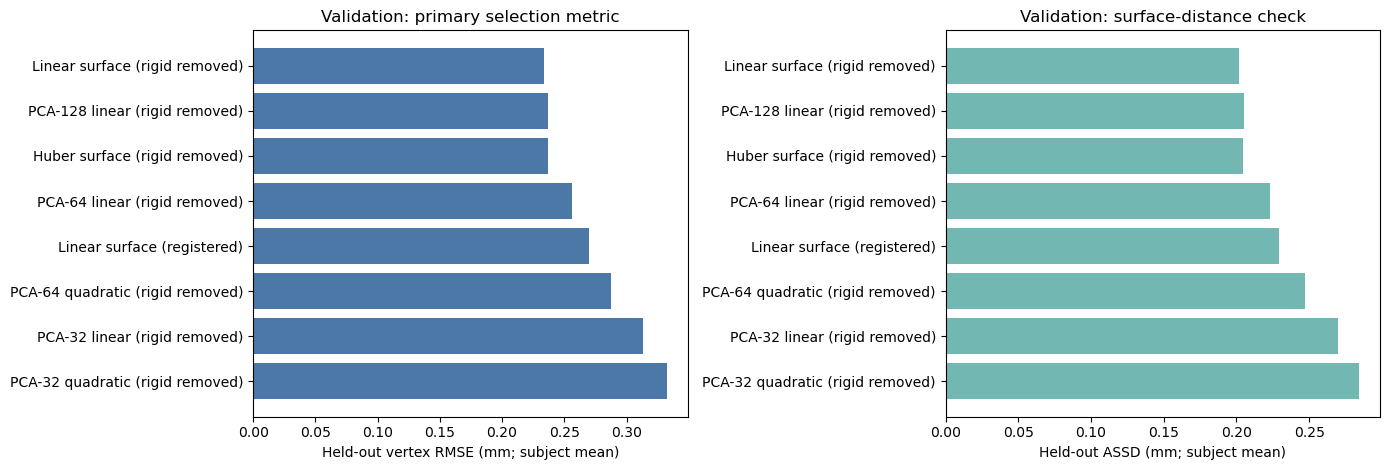

,candidate_label,candidate_kind,eligible_subjects,held_out_visits,subject_mean_vertex_rmse_mm,subject_mean_assd_mm,subject_mean_hd95_mm,subject_mean_log_volume_abs_error
0,Neighbour interpolation,baseline,57,147,0.2789,0.2363,0.4773,0.0153
1,No change from previous visit,baseline,57,147,0.3247,0.2713,0.5477,0.0214
2,Linear surface (rigid removed),trajectory,57,147,0.2336,0.2015,0.4031,0.0145
3,PCA-128 linear (rigid removed),trajectory,57,147,0.2369,0.2049,0.4065,0.0143
4,Huber surface (rigid removed),trajectory,57,147,0.2369,0.2042,0.4074,0.0145
5,PCA-64 linear (rigid removed),trajectory,57,147,0.2561,0.2229,0.4325,0.0143
6,Linear surface (registered),trajectory,57,147,0.2696,0.2291,0.4622,0.0145
7,PCA-64 quadratic (rigid removed),trajectory,45,135,0.2873,0.2469,0.4822,0.0162
8,PCA-32 linear (rigid removed),trajectory,57,147,0.3133,0.2695,0.5266,0.0145
9,PCA-32 quadratic (rigid removed),trajectory,45,135,0.3324,0.2845,0.5535,0.0162


In [3]:
plot = val_summary[val_summary.candidate_kind.eq("trajectory")].sort_values("subject_mean_vertex_rmse_mm")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].barh(plot.candidate_label, plot.subject_mean_vertex_rmse_mm, color="#4c78a8")
axes[0].invert_yaxis(); axes[0].set_xlabel("Held-out vertex RMSE (mm; subject mean)")
axes[0].set_title("Validation: primary selection metric")
axes[1].barh(plot.candidate_label, plot.subject_mean_assd_mm, color="#72b7b2")
axes[1].invert_yaxis(); axes[1].set_xlabel("Held-out ASSD (mm; subject mean)")
axes[1].set_title("Validation: surface-distance check")
plt.tight_layout(); plt.show()

display(val_summary[["candidate_label", "candidate_kind", "eligible_subjects", "held_out_visits",
                     "subject_mean_vertex_rmse_mm", "subject_mean_assd_mm", "subject_mean_hd95_mm",
                     "subject_mean_log_volume_abs_error"]].round(4))


## What rigid removal changes

**Registered vector RMS** includes residual translation and rotation as well as
shape change. **Rigid-removed vector RMS** is computed after subject-level rigid
alignment and is the shape-change rate used by the selected reference.
**Centroid speed** isolates translation. The speed ratio reports how much of the
registered interval rate remains after rigid removal; 1 means almost none was
removed. Consecutive interval cosine measures directional persistence: +1 is the
same direction, 0 is unrelated, and −1 is reversal.


,split,diagnosis,registered_vector_rms_mm_per_year,rigid_removed_vector_rms_mm_per_year,centroid_speed_mm_per_year,rigid_removed_to_registered_speed_ratio
0,test,AD,0.6121,0.5260,0.2153,0.8611
1,test,CN,0.4279,0.3668,0.1532,0.8649
2,val,AD,0.6181,0.5433,0.1912,0.8797
3,val,CN,0.4370,0.3765,0.1445,0.8669


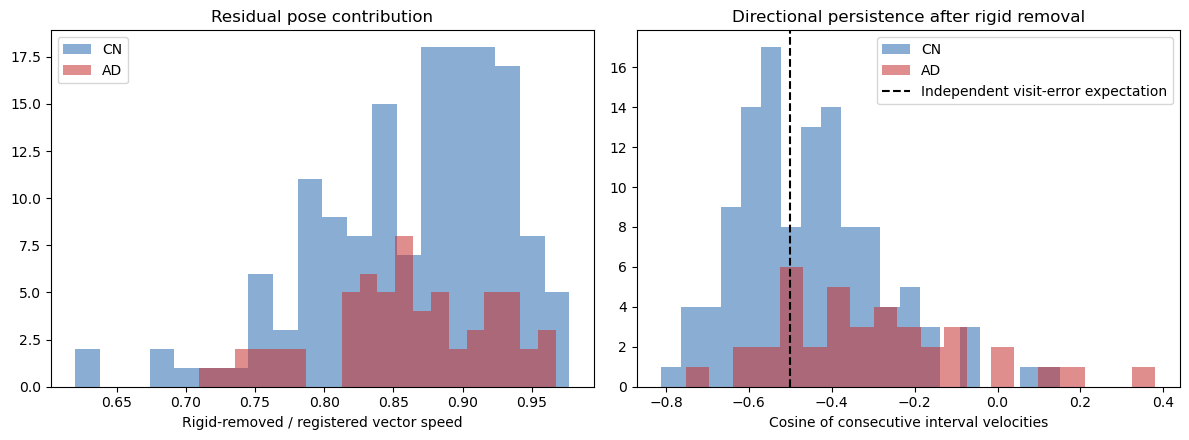

In [4]:
rigid_summary = intervals.groupby(["split", "diagnosis"])[[
    "registered_vector_rms_mm_per_year", "rigid_removed_vector_rms_mm_per_year",
    "centroid_speed_mm_per_year", "rigid_removed_to_registered_speed_ratio"
]].mean().reset_index()
display(rigid_summary.round(4))

test_intervals = intervals[intervals.split.eq("test")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for diagnosis in ("CN", "AD"):
    part = test_intervals[test_intervals.diagnosis.eq(diagnosis)]
    axes[0].hist(part.rigid_removed_to_registered_speed_ratio, bins=20, alpha=.55,
                 color=COLORS[diagnosis], label=diagnosis)
    axes[1].hist(part.next_rigid_removed_velocity_cosine.dropna(), bins=20, alpha=.55,
                 color=COLORS[diagnosis], label=diagnosis)
axes[0].set_xlabel("Rigid-removed / registered vector speed")
axes[0].set_title("Residual pose contribution")
axes[1].axvline(-0.5, color="black", linestyle="--", label="Independent visit-error expectation")
axes[1].set_xlabel("Cosine of consecutive interval velocities")
axes[1].set_title("Directional persistence after rigid removal")
for axis in axes: axis.legend()
plt.tight_layout(); plt.show()


## Why adjacent interval velocity can look wrong

If each registered visit contains independent position error, consecutive
differences share the middle visit with opposite signs. Under equal intervals
and dominant independent error, their expected correlation is −0.5 even when
the biological trajectory is smooth. A negative cosine near that value is thus
evidence that differentiation is amplifying visit-specific error; it is not
evidence that the hippocampus repeatedly reverses direction.

The next plot compares physical vector speed for the three observed definitions.
**Vector RMS** summarizes all three displacement components across vertices.
**Normal RMS** keeps only motion perpendicular to the surface, which is closer
to local expansion/contraction. **Adjacent/fitted ratio** above 1 means interval
differences are faster than the validation-selected smooth derivative.


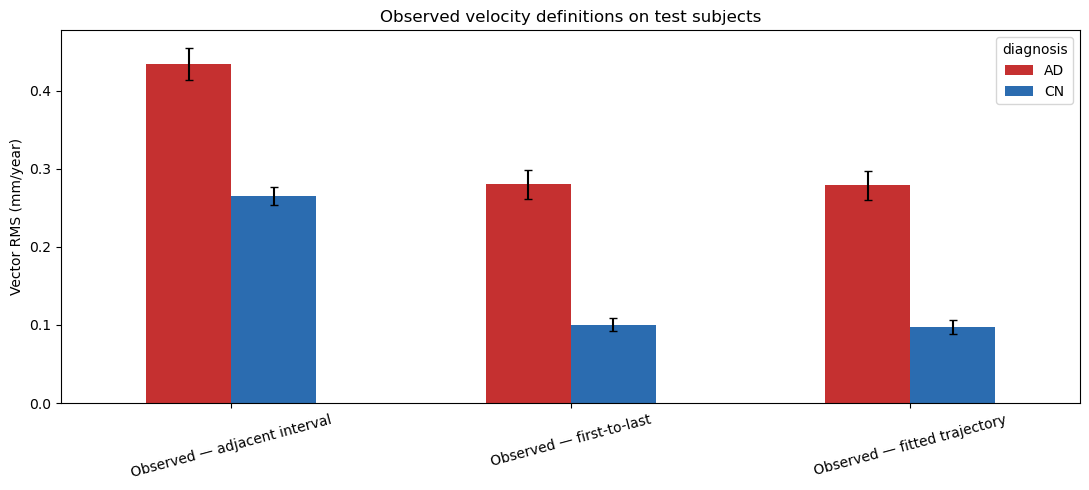

,fit_vector_rms_mm_per_year,adjacent_vector_rms_mm_per_year,endpoint_vector_rms_mm_per_year,adjacent_to_fit_speed_ratio,adjacent_fit_vector_cosine
diagnosis,,,,,
AD,0.2696,0.4260,0.2716,1.6557,0.6603
CN,0.0833,0.2483,0.0867,3.4402,0.3825


In [5]:
test_ref = reference[reference.split.eq("test")]
long_speed = test_ref.melt(
    id_vars=["subject_id", "diagnosis", "age_years"],
    value_vars=["adjacent_vector_rms_mm_per_year", "endpoint_vector_rms_mm_per_year", "fit_vector_rms_mm_per_year"],
    var_name="definition", value_name="vector_rms_mm_per_year")
labels = {
    "adjacent_vector_rms_mm_per_year": "Observed — adjacent interval",
    "endpoint_vector_rms_mm_per_year": "Observed — first-to-last",
    "fit_vector_rms_mm_per_year": "Observed — fitted trajectory",
}
long_speed["definition"] = long_speed.definition.map(labels)
subject_speed = long_speed.groupby(["definition", "diagnosis", "subject_id"], as_index=False).vector_rms_mm_per_year.mean()
means = subject_speed.groupby(["definition", "diagnosis"]).vector_rms_mm_per_year.mean().unstack()
errors = subject_speed.groupby(["definition", "diagnosis"]).vector_rms_mm_per_year.sem().unstack()
means = means.loc[list(labels.values())]
ax = means.plot.bar(yerr=errors.loc[means.index], figsize=(11, 5), color=[COLORS["AD"], COLORS["CN"]], capsize=3)
ax.set_ylabel("Vector RMS (mm/year)"); ax.set_xlabel("")
ax.set_title("Observed velocity definitions on test subjects")
ax.tick_params(axis="x", rotation=15); plt.tight_layout(); plt.show()

display(test_ref.groupby("diagnosis")[["fit_vector_rms_mm_per_year", "adjacent_vector_rms_mm_per_year",
                                      "endpoint_vector_rms_mm_per_year", "adjacent_to_fit_speed_ratio",
                                      "adjacent_fit_vector_cosine"]].mean().round(4))


## Interval trends with age and diagnosis

Each point below is one real adjacent interval located at its midpoint age.
Curves are age-bin means and shaded bands are standard errors across intervals;
they describe interval-average rates, not exact derivatives. **Normal mean** is
signed (negative is inward contraction when normals point outward). **Normal
RMS** is unsigned strength. **Log-volume rate** is percent volume change per year
and is easiest to interpret anatomically.


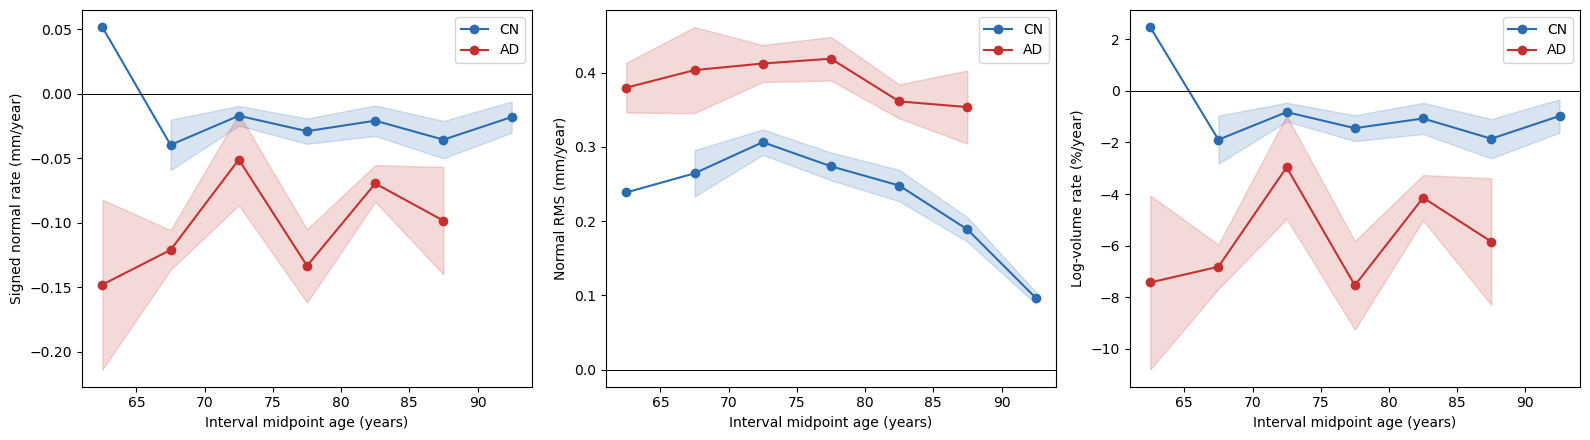

In [6]:
age_bins = np.arange(60, 96, 5)
interval_plot = test_intervals.copy()
interval_plot["age_bin"] = pd.cut(interval_plot.rigid_removed_age_mid_years, age_bins)
interval_plot["age_mid"] = interval_plot.age_bin.map(lambda x: x.mid if pd.notna(x) else np.nan).astype(float)
metrics = [
    ("rigid_removed_normal_mean_mm_per_year", "Signed normal rate (mm/year)"),
    ("rigid_removed_normal_rms_mm_per_year", "Normal RMS (mm/year)"),
    ("rigid_removed_log_volume_rate_percent_per_year", "Log-volume rate (%/year)"),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, (metric, ylabel) in zip(axes, metrics):
    for diagnosis in ("CN", "AD"):
        group = interval_plot[interval_plot.diagnosis.eq(diagnosis)].groupby("age_mid", observed=True)[metric]
        mean, error = group.mean(), group.sem()
        axis.plot(mean.index, mean, marker="o", color=COLORS[diagnosis], label=diagnosis)
        axis.fill_between(mean.index, mean-error, mean+error, color=COLORS[diagnosis], alpha=.18)
    axis.axhline(0, color="black", linewidth=.7); axis.set_xlabel("Interval midpoint age (years)")
    axis.set_ylabel(ylabel); axis.legend()
plt.tight_layout(); plt.show()


## AD versus CN volume trend

For each subject, a line is fitted to log volume versus age. Multiplying the
slope by 100 gives approximate percent change per year. Group means and 95%
confidence intervals use subject-level bootstrap resampling, so subjects with
more visits do not receive extra weight. The AD-minus-CN contrast is the primary
group comparison. The mixed-effects table additionally separates within-subject
aging from between-subject age differences; `age_within:label_ad` is the
longitudinal AD-versus-CN slope difference.


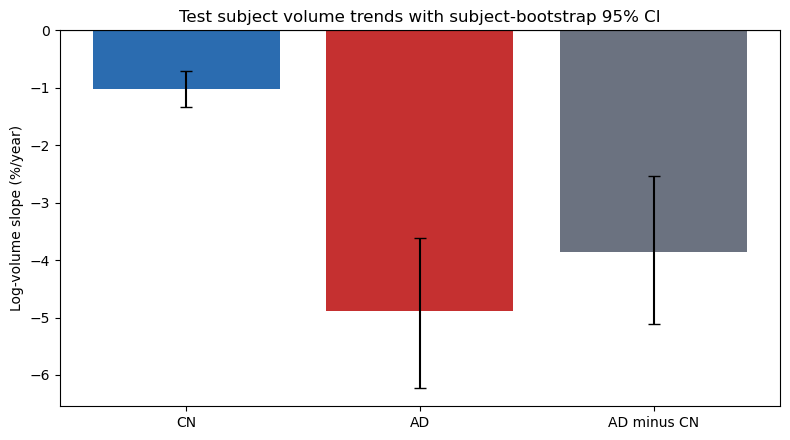

,split,metric,contrast,estimate,ci95_low,ci95_high,subjects
0,test,observed_log_volume_slope_percent_per_year,CN,-1.023,-1.332,-0.716,33
1,test,observed_log_volume_slope_percent_per_year,AD,-4.883,-6.234,-3.619,25
2,test,observed_log_volume_slope_percent_per_year,AD minus CN,-3.859,-5.112,-2.536,58


,split,term,estimate,standard_error,p_value,converged,subjects,scans
0,test,Intercept,8.25079,0.02204,0.0000,True,58,271
1,test,age_within,-0.01079,0.00075,0.0000,True,58,271
2,test,label_ad,-0.26375,0.03351,0.0000,True,58,271
3,test,age_within:label_ad,-0.03654,0.00340,0.0000,True,58,271
4,test,age_between,-0.00928,0.00267,0.0005,True,58,271


In [7]:
test_volume = volume_ci[(volume_ci.split.eq("test")) &
                        (volume_ci.metric.eq("observed_log_volume_slope_percent_per_year"))]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(test_volume))
colors = [COLORS.get(item, "#6b7280") for item in test_volume.contrast]
ax.bar(x, test_volume.estimate, color=colors)
ax.errorbar(x, test_volume.estimate,
            yerr=[test_volume.estimate-test_volume.ci95_low, test_volume.ci95_high-test_volume.estimate],
            fmt="none", ecolor="black", capsize=4)
ax.axhline(0, color="black", linewidth=.8)
ax.set_xticks(x, test_volume.contrast); ax.set_ylabel("Log-volume slope (%/year)")
ax.set_title("Test subject volume trends with subject-bootstrap 95% CI")
plt.tight_layout(); plt.show()
display(test_volume.round(3))
display(mixed[mixed.split.eq("test")].round(5))


## Reference stability and gap sensitivity

**Leave-one-visit-out derivative cosine** compares the derivative from all
visits with the derivative after one visit is removed; closer to 1 is more
stable. **Relative derivative error** is the change in derivative norm divided
by the full-fit norm; closer to 0 is better. Gap sensitivity checks whether
short intervals create larger adjacent rates, as expected when fixed position
error is divided by a smaller elapsed time.


derivative_cosine              relative_derivative_error  \
                             mean median count                      mean   
split diagnosis                                                            
test  AD                    0.873  0.966    49                     0.486   
      CN                    0.902  0.977   174                     0.456   
val   AD                    0.863  0.963    64                     0.522   
      CN                    0.909  0.972   161                     0.425   

                             speed_ratio               
                median count        mean median count  
split diagnosis                                        
test  AD         0.265    49       1.160  1.032    49  
      CN         0.226   174       1.186  1.025   174  
val   AD         0.372    64       1.188  1.054    64  
      CN         0.243   161       1.154  1.027   161

registered_vector_rms_mm_per_year  \
gap_bin    diagnosis                                      
≤0.75 y    AD                                    0.6746   
           CN                                    0.6159   
0.75–1.5 y AD                                    0.4119   
           CN                                    0.3263   
>1.5 y     CN                                    0.1588   

                      rigid_removed_vector_rms_mm_per_year  
gap_bin    diagnosis                                        
≤0.75 y    AD                                       0.5802  
           CN                                       0.5237  
0.75–1.5 y AD                                       0.3523  
           CN                                       0.2833  
>1.5 y     CN                                       0.1374

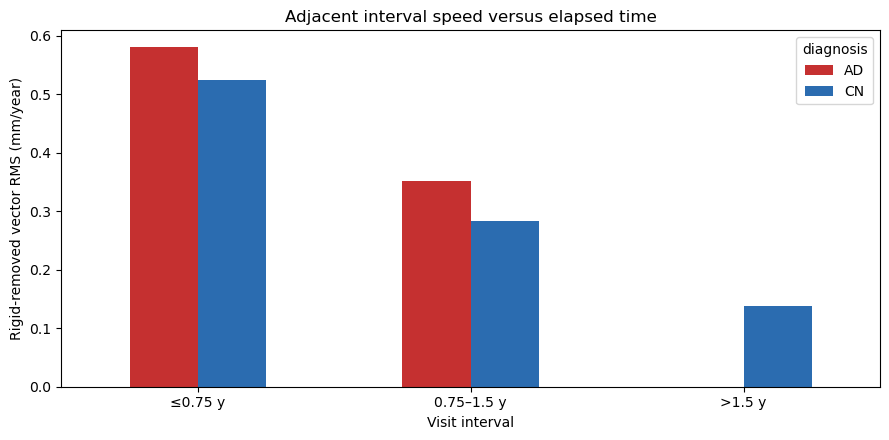

In [8]:
display(stability.groupby(["split", "diagnosis"])[["derivative_cosine", "relative_derivative_error", "speed_ratio"]]
        .agg(["mean", "median", "count"]).round(3))

gap = test_intervals.copy()
gap["gap_bin"] = pd.cut(gap.registered_gap_years, [0, .75, 1.5, np.inf], labels=["≤0.75 y", "0.75–1.5 y", ">1.5 y"])
gap_summary = gap.groupby(["gap_bin", "diagnosis"], observed=True)[[
    "registered_vector_rms_mm_per_year", "rigid_removed_vector_rms_mm_per_year"
]].mean()
display(gap_summary.round(4))
ax = gap_summary["rigid_removed_vector_rms_mm_per_year"].unstack().plot.bar(
    figsize=(9, 4.5), color=[COLORS["AD"], COLORS["CN"]])
ax.set_ylabel("Rigid-removed vector RMS (mm/year)"); ax.set_xlabel("Visit interval")
ax.set_title("Adjacent interval speed versus elapsed time"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()


## Latent-space instantaneous velocity

For each representation, the trained flow returns a local latent velocity at a
shape and age. **Model speed** is its RMS magnitude per coordinate. **Observed —
fitted trajectory speed** is the derivative of a linear subject trajectory in
that same train-standardized latent coordinate system. **Observed — adjacent
interval speed** is the differenced latent rate. These units are specific to
each representation, so absolute magnitudes must be compared only within a
method, never across methods. Speed agreement does not establish vector
direction agreement.


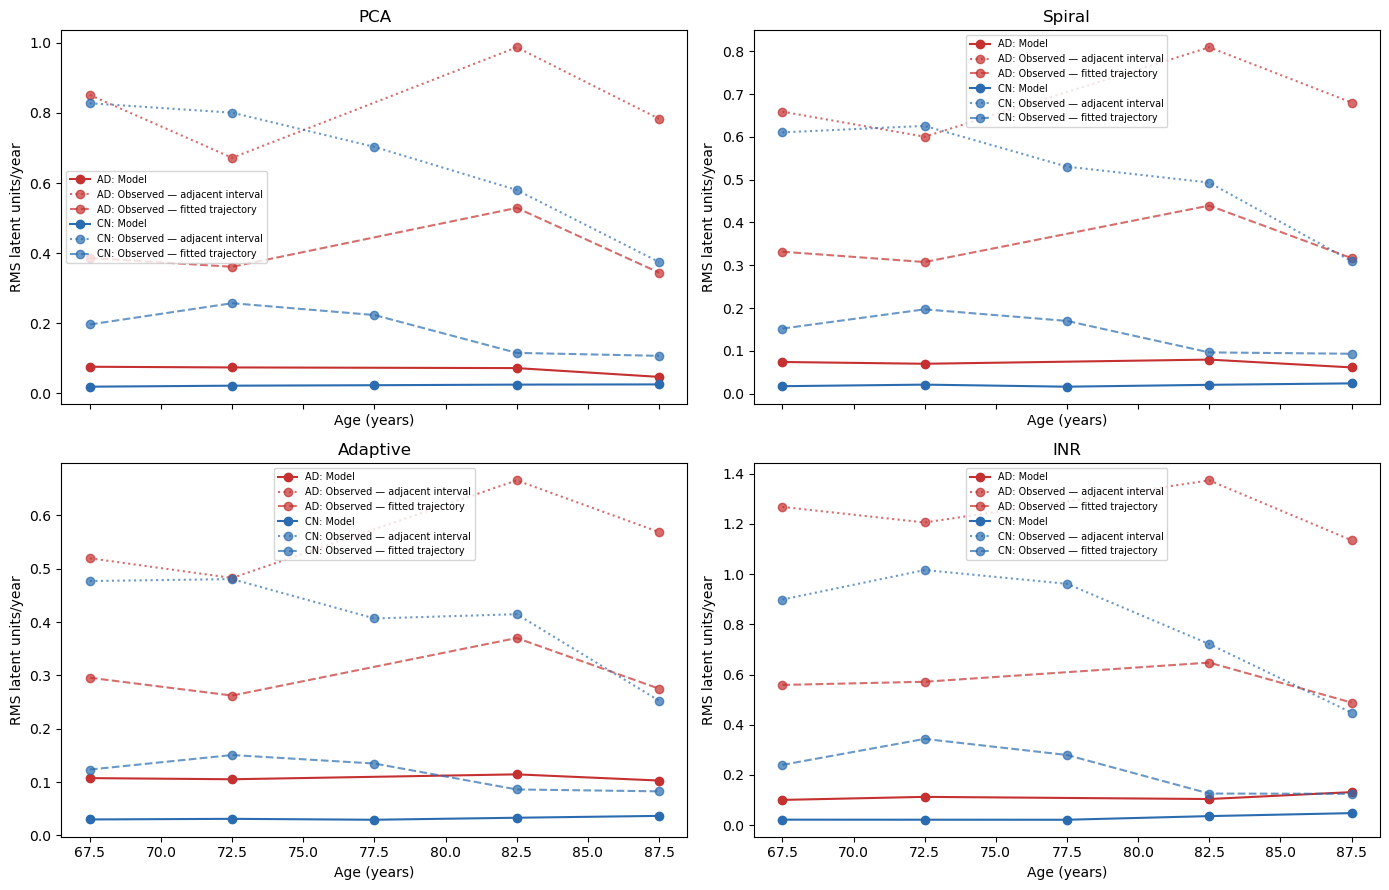

In [9]:
latent_long = latent.melt(
    id_vars=["method_label", "diagnosis", "age_years", "subject_id"],
    value_vars=["model_rms_per_coordinate_per_year", "fitted_rms_per_coordinate_per_year", "adjacent_rms_per_coordinate_per_year"],
    var_name="source", value_name="speed")
latent_labels = {
    "model_rms_per_coordinate_per_year": "Model",
    "fitted_rms_per_coordinate_per_year": "Observed — fitted trajectory",
    "adjacent_rms_per_coordinate_per_year": "Observed — adjacent interval",
}
latent_long["source"] = latent_long.source.map(latent_labels)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for axis, (method, frame) in zip(axes.flat, latent_long.groupby("method_label", sort=False)):
    frame = frame.copy(); frame["age_bin"] = pd.cut(frame.age_years, np.arange(60, 96, 5))
    frame["age_mid"] = frame.age_bin.map(lambda x: x.mid if pd.notna(x) else np.nan).astype(float)
    for (diagnosis, source), part in frame.groupby(["diagnosis", "source"], observed=True):
        mean = part.groupby("age_mid", observed=True).speed.mean()
        style = "-" if source == "Model" else ("--" if "fitted" in source else ":")
        axis.plot(mean.index, mean, linestyle=style, marker="o", color=COLORS[diagnosis],
                  alpha=1 if source == "Model" else .7, label=f"{diagnosis}: {source}")
    axis.set_title(method); axis.set_ylabel("RMS latent units/year"); axis.set_xlabel("Age (years)")
    axis.legend(fontsize=7)
plt.tight_layout(); plt.show()


## Surface-space instantaneous velocity for current models

The decoder maps each model's local change into physical surface motion.
**Normal MAE/RMSE** measure field error in mm/year. **Pearson correlation**
measures spatial pattern after removing the mean. **Sign agreement** is the
surface-area fraction with matching inward/outward direction. **Hotspot Dice**
compares the strongest 20% of absolute changes. **Speed ratio** compares RMS
magnitude; 1 is matched scale. Metrics are computed on diagnosis-specific,
subject-then-group averaged fields on the shared 20-subject test cohort.


,cohort,method,method_label,diagnosis,comparator,subjects,scans,normal_mae_mm_per_year,normal_rmse_mm_per_year,normal_pearson,normal_sign_agreement,hotspot_dice,model_to_reference_speed_ratio
0,current_shared_test,pca,PCA,CN,Observed — fitted trajectory,13,73,0.0174,0.0220,0.7169,0.8462,0.5527,0.7901
1,current_shared_test,pca,PCA,AD,Observed — fitted trajectory,7,27,0.0403,0.0499,0.7031,0.9108,0.5891,0.9719
2,current_shared_test,pca,PCA,AD minus CN,Observed — fitted trajectory group difference,20,100,0.0477,0.0595,0.4228,0.8413,0.3891,0.9107
3,current_shared_test,spiral,Spiral,CN,Observed — fitted trajectory,13,73,0.0179,0.0227,0.6970,0.8534,0.5036,0.7627
4,current_shared_test,spiral,Spiral,AD,Observed — fitted trajectory,7,27,0.0401,0.0487,0.7335,0.9165,0.6018,1.0183
5,current_shared_test,spiral,Spiral,AD minus CN,Observed — fitted trajectory group difference,20,100,0.0482,0.0593,0.4514,0.8453,0.4055,0.9578
6,current_shared_test,adaptive,Adaptive,CN,Observed — fitted trajectory,13,73,0.0179,0.0226,0.6979,0.8530,0.5109,0.7693
7,current_shared_test,adaptive,Adaptive,AD,Observed — fitted trajectory,7,27,0.0377,0.0466,0.7457,0.9175,0.6200,0.9718
8,current_shared_test,adaptive,Adaptive,AD minus CN,Observed — fitted trajectory group difference,20,100,0.0455,0.0564,0.4833,0.8465,0.4109,0.8995
9,current_shared_test,inr,INR,CN,Observed — fitted trajectory,13,73,0.0226,0.0286,0.6658,0.8378,0.4927,0.4093


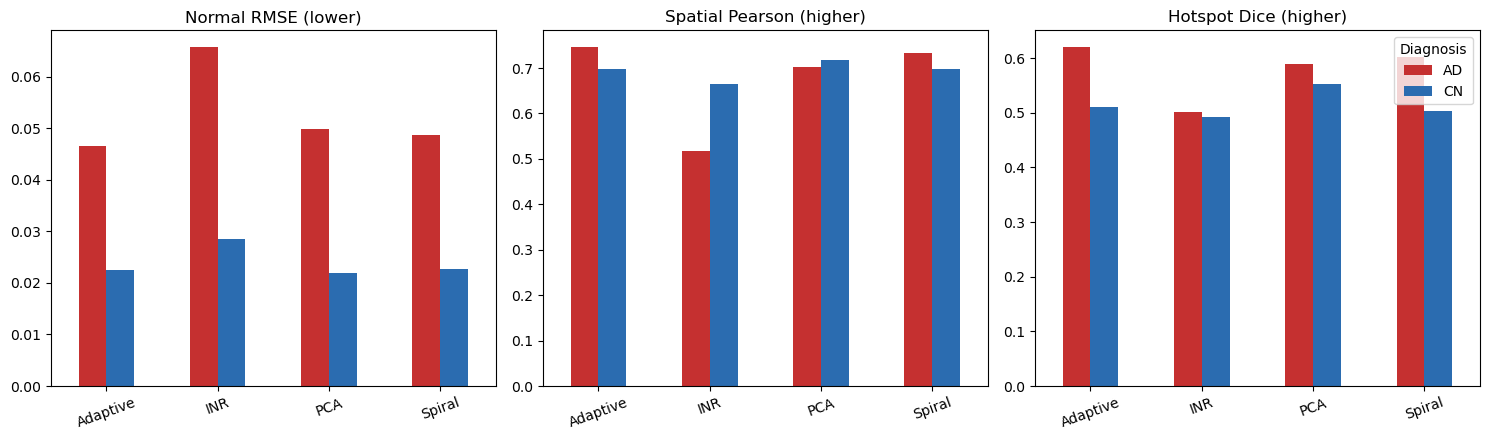

In [10]:
display(current_surface.round(4))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for axis, metric, title in zip(axes,
    ["normal_rmse_mm_per_year", "normal_pearson", "hotspot_dice"],
    ["Normal RMSE (lower)", "Spatial Pearson (higher)", "Hotspot Dice (higher)"]):
    frame = current_surface[current_surface.diagnosis.ne("AD minus CN")]
    pivot = frame.pivot(index="method_label", columns="diagnosis", values=metric)
    pivot.plot.bar(ax=axis, color=[COLORS["AD"], COLORS["CN"]], legend=False)
    axis.set_title(title); axis.set_xlabel(""); axis.tick_params(axis="x", rotation=20)
axes[-1].legend(title="Diagnosis")
plt.tight_layout(); plt.show()


## Comparison with the previous instantaneous-velocity result

This sensitivity analysis keeps each current model field and shared cohort
fixed, changing only the observed comparator. The previous analysis used the
adjacent interval field; the corrected analysis uses the validation-selected
fitted trajectory. Changes in RMSE or correlation therefore quantify how much
the earlier conclusion depended on noisy interval differentiation. They do not
represent retraining or a new checkpoint.


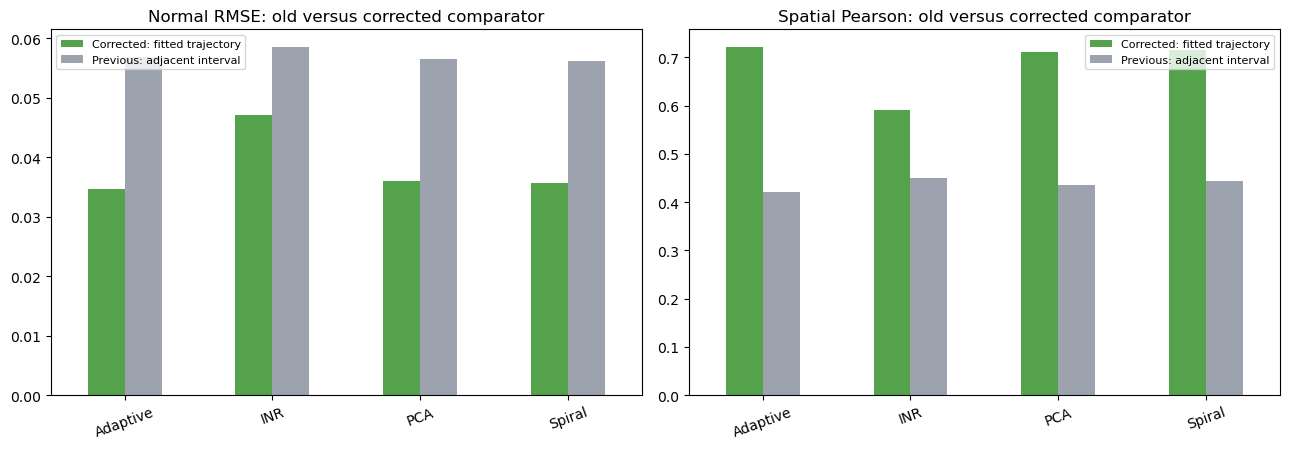

,cohort,method,method_label,diagnosis,comparator,normal_mae_mm_per_year,normal_rmse_mm_per_year,normal_pearson,normal_sign_agreement,hotspot_dice,model_to_reference_speed_ratio
0,current_shared_test,pca,PCA,CN,Previous: Observed — adjacent interval,0.0282,0.0340,0.3516,0.7442,0.3527,0.7395
1,current_shared_test,pca,PCA,AD,Previous: Observed — adjacent interval,0.0646,0.0788,0.5175,0.8161,0.4836,0.8969
2,current_shared_test,pca,PCA,AD minus CN,Previous: Observed — adjacent interval group d...,0.0775,0.0960,0.3217,0.6930,0.3927,0.7001
3,current_shared_test,spiral,Spiral,CN,Previous: Observed — adjacent interval,0.0277,0.0338,0.3472,0.7458,0.3091,0.7137
4,current_shared_test,spiral,Spiral,AD,Previous: Observed — adjacent interval,0.0648,0.0785,0.5408,0.8247,0.4909,0.9397
5,current_shared_test,spiral,Spiral,AD minus CN,Previous: Observed — adjacent interval group d...,0.0775,0.0955,0.3477,0.7037,0.3964,0.7361
6,current_shared_test,adaptive,Adaptive,CN,Previous: Observed — adjacent interval,0.0282,0.0342,0.3348,0.7422,0.3055,0.7201
7,current_shared_test,adaptive,Adaptive,AD,Previous: Observed — adjacent interval,0.0660,0.0796,0.5065,0.8209,0.4800,0.8968
8,current_shared_test,adaptive,Adaptive,AD minus CN,Previous: Observed — adjacent interval group d...,0.0784,0.0961,0.3157,0.6985,0.3873,0.6913
9,current_shared_test,inr,INR,CN,Previous: Observed — adjacent interval,0.0276,0.0344,0.4437,0.7584,0.3527,0.3828


In [11]:
sense = comparator_sensitivity[comparator_sensitivity.diagnosis.isin(["CN", "AD"])].copy()
sense["comparator_short"] = np.where(sense.comparator.str.startswith("Previous"),
                                     "Previous: adjacent interval", "Corrected: fitted trajectory")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for axis, metric, title in zip(axes,
    ["normal_rmse_mm_per_year", "normal_pearson"],
    ["Normal RMSE", "Spatial Pearson"]):
    summary = sense.groupby(["method_label", "comparator_short"])[metric].mean().unstack()
    summary.plot.bar(ax=axis, color=["#54a24b", "#9ca3af"])
    axis.set_title(f"{title}: old versus corrected comparator")
    axis.set_xlabel(""); axis.tick_params(axis="x", rotation=20)
    axis.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(comparator_sensitivity.round(4))


## One averaged surface-change map per current method

Each panel is one group-averaged surface field, not a collection of individual
meshes. The displayed quantity is AD-minus-CN signed normal velocity. Blue is a
more inward AD rate; red is a more outward AD rate. The observed panel uses the
fitted-trajectory reference on exactly the scans shared by all current models.
All panels share one symmetric colour range.


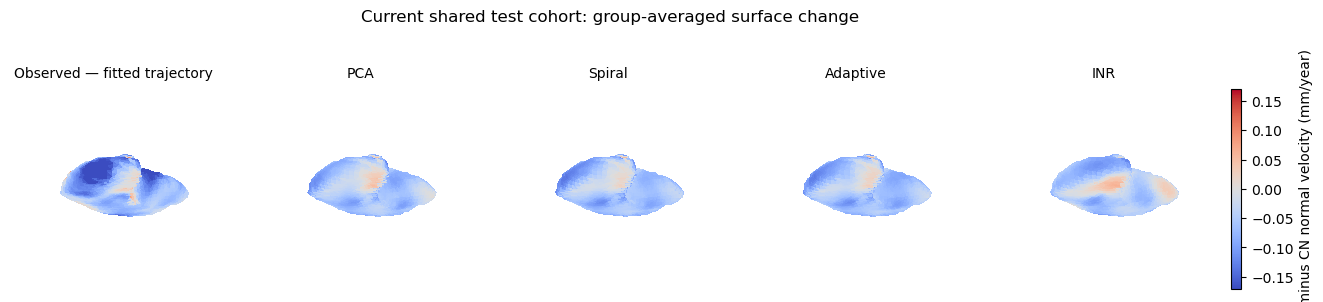

In [12]:
config = json.loads((TASK / "configs" / "velocity_reference_audit.json").read_text())
def resolve_path(value):
    path = Path(value)
    return path if path.is_absolute() else TASK.parents[2] / path
old_root = resolve_path(config["existing_surface_velocity_cache"])
with np.load(CACHE / "arrays" / "test_velocity_reference.npz", allow_pickle=False) as z:
    ref_arrays = {k: z[k] for k in z.files}
with np.load(old_root / "arrays" / "current_instantaneous_surface_maps.npz", allow_pickle=False) as z:
    current_maps = {k: z[k] for k in z.files}
old_table = pd.read_csv(old_root / "tables" / "current_instantaneous_surface_velocity.csv", dtype={"scan_id": str})
mask = np.isin(ref_arrays["scan_ids"].astype(str), old_table.scan_id.unique())
shared_fields = ref_arrays["fitted_normal_velocity"][mask]
shared_subjects = ref_arrays["subject_ids"][mask].astype(str)
shared_diagnoses = ref_arrays["diagnoses"][mask].astype(str)
observed_gap = (subject_group_mean(shared_fields, shared_subjects, shared_diagnoses, "AD") -
                subject_group_mean(shared_fields, shared_subjects, shared_diagnoses, "CN"))
current_fields = [observed_gap] + [current_maps[f"{m}_model_group_gap"] for m in ("pca", "spiral", "adaptive", "inr")]
current_titles = ["Observed — fitted trajectory", "PCA", "Spiral", "Adaptive", "INR"]

def surface_panels(vertices, faces, fields, titles, heading):
    vertices = np.asarray(vertices); faces = np.asarray(faces)
    limit = np.quantile(np.abs(np.concatenate([np.ravel(v) for v in fields])), .98)
    fig = plt.figure(figsize=(3.2 * len(fields), 3.7))
    for index, (field, title) in enumerate(zip(fields, titles), 1):
        axis = fig.add_subplot(1, len(fields), index, projection="3d")
        surface = axis.plot_trisurf(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                                    triangles=faces, linewidth=0, antialiased=False,
                                    cmap="coolwarm", vmin=-limit, vmax=limit, shade=False)
        surface.set_array(np.asarray(field)[faces].mean(axis=1))
        axis.set_title(title, fontsize=10); axis.set_axis_off(); axis.view_init(elev=18, azim=-65)
    fig.suptitle(heading, y=.98)
    bar = fig.colorbar(surface, ax=fig.axes, fraction=.015, pad=.02, shrink=.7)
    bar.set_label("AD minus CN normal velocity (mm/year)")
    plt.show()

surface_panels(ref_arrays["template_vertices"], ref_arrays["faces"], current_fields, current_titles,
               "Current shared test cohort: group-averaged surface change")


## Legacy ODE and BrainODE comparison — separate cohort

These completed legacy models use a different cohort and preprocessing
contract. Their comparator is **Observed — adjacent interval**, not the newly
selected fitted trajectory. Therefore this section can compare PCA Cocycle, INR
Cocycle, Latent ODE, and BrainODE within the legacy cohort, but its numbers must
not be ranked against current-model numbers. The same field metrics retain the
definitions given above.


,cohort,method,method_label,diagnosis,comparator,subjects,scans,normal_mae_mm_per_year,normal_rmse_mm_per_year,normal_pearson,normal_sign_agreement,hotspot_dice,model_to_reference_speed_ratio
0,legacy_reference_test,pca_cocycle,PCA Cocycle,CN,Observed — adjacent interval (legacy cohort; n...,29,149,0.0546,0.0712,0.3205,0.6058,0.3552,0.2271
1,legacy_reference_test,pca_cocycle,PCA Cocycle,AD,Observed — adjacent interval (legacy cohort; n...,21,65,0.0931,0.1218,0.4601,0.7269,0.4977,0.1883
2,legacy_reference_test,inr_cocycle,INR Cocycle,CN,Observed — adjacent interval (legacy cohort; n...,29,149,0.0564,0.0732,0.3146,0.5204,0.3597,0.3909
3,legacy_reference_test,inr_cocycle,INR Cocycle,AD,Observed — adjacent interval (legacy cohort; n...,21,65,0.1056,0.1380,0.2375,0.5720,0.1109,0.3602
4,legacy_reference_test,latent_ode,Latent ODE,CN,Observed — adjacent interval (legacy cohort; n...,29,149,0.0715,0.0976,0.0857,0.5089,0.3982,0.8149
5,legacy_reference_test,latent_ode,Latent ODE,AD,Observed — adjacent interval (legacy cohort; n...,21,65,0.1419,0.1835,0.3514,0.5266,0.2783,1.0054
6,legacy_reference_test,brainode,BrainODE,CN,Observed — adjacent interval (legacy cohort; n...,29,149,0.0499,0.0643,0.5880,0.6657,0.3032,0.4367
7,legacy_reference_test,brainode,BrainODE,AD,Observed — adjacent interval (legacy cohort; n...,21,65,0.0919,0.1195,0.4169,0.7122,0.4163,0.2457


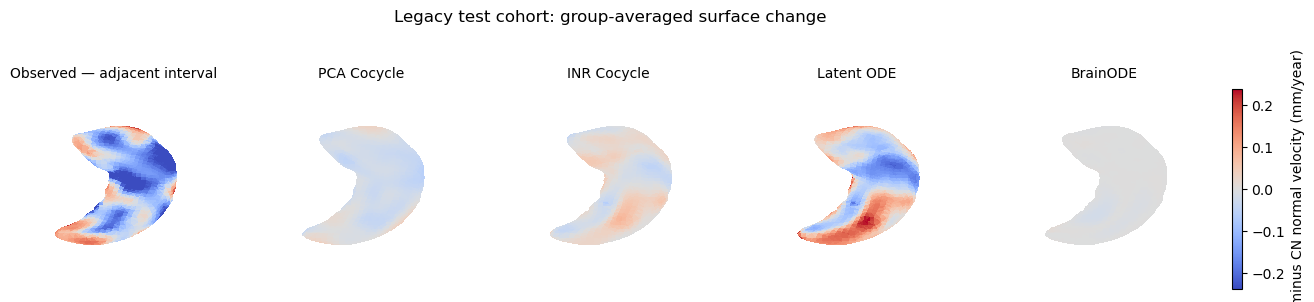

In [13]:
display(legacy_surface.round(4))
with np.load(old_root / "arrays" / "legacy_instantaneous_surface_maps.npz", allow_pickle=False) as z:
    legacy_maps = {k: z[k] for k in z.files}
legacy_methods = ["pca_cocycle", "inr_cocycle", "latent_ode", "brainode"]
legacy_titles = ["Observed — adjacent interval", "PCA Cocycle", "INR Cocycle", "Latent ODE", "BrainODE"]
legacy_fields = [legacy_maps["observed_gt_group_gap"]] + [legacy_maps[f"{m}_model_group_gap"] for m in legacy_methods]
surface_panels(legacy_maps["template_vertices"], legacy_maps["faces"], legacy_fields, legacy_titles,
               "Legacy test cohort: group-averaged surface change")


## Dedicated representation-size comparison

This is the only section that exposes representation size. The comparison is
descriptive because size and decoder family change together: three registered
mesh models use 128 coordinates, while the implicit model uses 256. It is not a
controlled ablation of dimension alone. All surface metrics remain in physical
units and use the same shared current test cohort.


In [14]:
size_table = pd.read_csv(tables / "dedicated_128_256_surface_comparison.csv")
display(size_table[["method_label", "latent_dimension", "diagnosis", "normal_rmse_mm_per_year",
                    "normal_pearson", "hotspot_dice", "model_to_reference_speed_ratio"]].round(4))


,method_label,latent_dimension,diagnosis,normal_rmse_mm_per_year,normal_pearson,hotspot_dice,model_to_reference_speed_ratio
0,PCA,128,CN,0.0220,0.7169,0.5527,0.7901
1,PCA,128,AD,0.0499,0.7031,0.5891,0.9719
2,PCA,128,AD minus CN,0.0595,0.4228,0.3891,0.9107
3,Spiral,128,CN,0.0227,0.6970,0.5036,0.7627
4,Spiral,128,AD,0.0487,0.7335,0.6018,1.0183
5,Spiral,128,AD minus CN,0.0593,0.4514,0.4055,0.9578
6,Adaptive,128,CN,0.0226,0.6979,0.5109,0.7693
7,Adaptive,128,AD,0.0466,0.7457,0.6200,0.9718
8,Adaptive,128,AD minus CN,0.0564,0.4833,0.4109,0.8995
9,INR,256,CN,0.0286,0.6658,0.4927,0.4093


## Interpretation summary

- The validation-selected linear rigid-removed trajectory predicted omitted
  visits better than raw-coordinate, robust, low-rank, and quadratic candidates.
- Negative consecutive interval direction and strong short-gap rates show why
  adjacent differences should not be labeled instantaneous ground truth.
- The fitted trajectory yields a smoother physical and latent-space reference,
  but it assumes approximately linear within-subject change over the observed
  span and cannot establish rapid biological fluctuations.
- AD has a more negative test log-volume slope than CN; inference is performed
  at the subject level, with the within-subject mixed-effects interaction shown
  separately.
- Current model comparisons use one shared cohort and physical surface units.
  Legacy ODE/BrainODE results remain a separate within-cohort analysis.

Use these results as a reliability audit and model diagnostic. A stronger claim
about true instantaneous biology would require denser acquisitions, scan-rescan
repeatability data, or an explicit measurement-error model validated outside
this cohort.
